# Notebook 25. Continuous Spell Evolution and Onset Timing

This notebook is the broader time-evolution follow-on to `Notebooks 22–23`.

It is designed for the problem we uncovered in the peak-event method:

- some offshore-to-coastal or coastal-to-offshore evolution may happen between catalog peaks
- later stages can be missed if they never became their own event peak
- we still want those stages to count when they are visible in the underlying ERA5 fields

So this notebook:

- builds broader catalog timing groups from chronology only
- pads each timing-group window by `+/- 48 h`
- computes continuous polygon and coastal-only moisture/divergence metrics
- applies candidate threshold profiles through time with a persistence rule
- estimates onset order and lag from the continuous timing-group windows instead of peak-event order alone


In [22]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = os.environ.get("JPCZ_CATALOG_BRANCH", "codex/notebook16-pcolormesh")
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = False
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

def clone_repo_branch():
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )

def sync_repo_branch():
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", "-B", BRANCH, f"origin/{BRANCH}"], check=True)


if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    clone_repo_branch()
else:
    print("Using existing repo clone:", REPO_DIR)

try:
    sync_repo_branch()
except subprocess.CalledProcessError:
    print("Existing clone could not switch branches cleanly. Re-cloning target branch.")
    if os.path.exists(REPO_DIR):
        shutil.rmtree(REPO_DIR)
    clone_repo_branch()
    sync_repo_branch()

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

active_branch = subprocess.run(["git", "-C", REPO_DIR, "branch", "--show-current"], text=True, capture_output=True, check=True).stdout.strip()
print("Working directory:", os.getcwd())
print("Runtime repo branch:", active_branch)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs
Using existing repo clone: /content/JPCZcatalog
Working directory: /content/JPCZcatalog
Runtime repo branch: codex/notebook16-pcolormesh


In [23]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import JPCZ_POLYGON_VERTICES, OBJECTIVE_SUBTYPE_DOMAIN
from jpcz_catalog.era5 import open_arco_era5, subset_era5_window
from jpcz_catalog.objective_regimes import summarize_padded_spell_windows
from jpcz_catalog.spell_evolution import (
    apply_continuous_regime_thresholds,
    compute_window_regional_metric_timeseries,
    prepare_objective_region_weights,
    summarize_continuous_spell,
)

OBJECTIVE_EXPORT_DIR = Path("outputs/verification/objective_coastal_box_regimes")
TIMING_EXPORT_DIR = Path("outputs/verification/objective_regime_timing_and_impact")
TIMING_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("outputs/verification/objective_regime_timing_and_impact_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

OBJECTIVE_EVENT_METRICS_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_event_metrics.csv"
THRESHOLD_SWEEP_INPUT_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_threshold_sensitivity.csv"
VERIFICATION_DIR = Path("outputs/verification")
POSITION_INTENSITY_PATH = VERIFICATION_DIR / "jpcz_catalog_ndjf_merged_12h_position_intensity.csv"

ERA5_TIME_CHUNK = 48
SMOKE_TEST_MODE = False
SMOKE_TEST_PROFILE = "balanced_looser"
SMOKE_TEST_SPELL_LIMIT = 10
FORCE_REBUILD_SPELL_TABLES = False
FORCE_REBUILD_CONTINUOUS_BASE = False
FORCE_REBUILD_THRESHOLD_APPLICATION = False
CONTINUOUS_SPELL_GAP_HOURS = 36
CONTINUOUS_PADDING_HOURS = 48
CONTINUOUS_TIME_STEP_HOURS = 6
CONTINUOUS_PERSISTENCE_STEPS = 2
CONTINUOUS_CHECKPOINT_EVERY_SPELLS = 5
CONTINUOUS_SPELL_LIMIT = None
CONTINUOUS_PROFILE_FILTER = None
CONTINUOUS_PLOT_PROFILE = "balanced_looser"
CONTINUOUS_PLOT_SPELL_ID = None

if SMOKE_TEST_MODE:
    FORCE_REBUILD_CONTINUOUS_BASE = True
    FORCE_REBUILD_THRESHOLD_APPLICATION = True
    CONTINUOUS_SPELL_LIMIT = SMOKE_TEST_SPELL_LIMIT
    CONTINUOUS_PROFILE_FILTER = SMOKE_TEST_PROFILE

COASTAL_STRIP_VERTICES = (
    (133.05, 35.55),
    (136.05, 35.55),
    (139.55, 39.00),
    (139.55, 42.55),
)

if CONTINUOUS_PROFILE_FILTER is None:
    continuous_profile_tag = "allprofiles"
elif isinstance(CONTINUOUS_PROFILE_FILTER, str):
    continuous_profile_tag = str(CONTINUOUS_PROFILE_FILTER)
else:
    continuous_profile_tag = "-".join(str(value) for value in CONTINUOUS_PROFILE_FILTER)
continuous_limit_tag = "allspells" if CONTINUOUS_SPELL_LIMIT is None else f"first{int(CONTINUOUS_SPELL_LIMIT):03d}"
continuous_mode_tag = "smoketest" if SMOKE_TEST_MODE else "fullrun"
CONTINUOUS_RUN_TAG = f"{continuous_mode_tag}_{continuous_profile_tag}_{continuous_limit_tag}"

CONTINUOUS_CANDIDATE_THRESHOLDS_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_candidate_thresholds_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_SPELL_EVENT_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_spell_events_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_SPELL_WINDOW_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_spell_windows_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_BASE_TIMESERIES_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_base_spell_timeseries_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_BASE_SPELL_SUMMARY_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_base_spell_summary_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_LABELED_TIMESERIES_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_labeled_spell_timeseries_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_SUMMARY_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_spell_summary_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_PROFILE_SUMMARY_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_profile_summary_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_EXAMPLES_PATH = TIMING_EXPORT_DIR / f"objective_regime_continuous_spell_examples_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.csv"
CONTINUOUS_PLOT_PATH = PLOT_DIR / f"objective_regime_continuous_spell_profile_{CONTINUOUS_PLOT_PROFILE}_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h_pad{CONTINUOUS_PADDING_HOURS:02d}h_{CONTINUOUS_RUN_TAG}.png"


def maybe_copy_to_drive(path: Path, *, verbose: bool = True):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return None
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        if verbose:
            print("Copied to Drive:", drive_path)
        return drive_path
    return None


def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive cache:", drive_path)
    return True


In [24]:
paths_to_restore = [
    OBJECTIVE_EVENT_METRICS_PATH,
    THRESHOLD_SWEEP_INPUT_PATH,
    POSITION_INTENSITY_PATH,
]
for path in paths_to_restore:
    if not path.exists():
        restore_from_drive_cache(path)

if not OBJECTIVE_EVENT_METRICS_PATH.exists():
    raise RuntimeError("Run Notebook 22 first so the objective event-label table exists.")
if not THRESHOLD_SWEEP_INPUT_PATH.exists():
    raise RuntimeError("Run Notebook 22 first so the full threshold-sensitivity table exists.")
if not POSITION_INTENSITY_PATH.exists():
    raise RuntimeError("Run Notebook 05 first so the merged 12 h position/intensity catalog exists.")

objective_df = pd.read_csv(
    OBJECTIVE_EVENT_METRICS_PATH,
    parse_dates=[
        column
        for column in ["event_start", "event_end", "event_peak", "event_peak_jst"]
        if column in pd.read_csv(OBJECTIVE_EVENT_METRICS_PATH, nrows=0).columns
    ],
)
objective_df = add_japan_local_time_columns(objective_df)
if "event_index" not in objective_df.columns:
    objective_df["event_index"] = objective_df.index.astype(int)

position_df = pd.read_csv(
    POSITION_INTENSITY_PATH,
    parse_dates=[column for column in ["event_start", "event_end", "event_peak"] if column in pd.read_csv(POSITION_INTENSITY_PATH, nrows=0).columns],
)
if "event_index" not in position_df.columns:
    position_df["event_index"] = position_df.index.astype(int)
position_df = add_japan_local_time_columns(position_df)
position_merge_columns = [column for column in [
    "event_index",
    "event_start",
    "event_end",
    "event_peak",
    "event_peak_jst",
    "duration_hours",
    "episode_span_hours",
] if column in position_df.columns]
position_merge_df = position_df[position_merge_columns].copy()
objective_df = objective_df.merge(position_merge_df, on="event_index", how="left", suffixes=("", "_position"))
for column in ["event_start", "event_end", "event_peak", "event_peak_jst"]:
    fallback_column = f"{column}_position"
    if column in objective_df.columns and fallback_column in objective_df.columns:
        objective_df[column] = objective_df[column].fillna(objective_df[fallback_column])
        objective_df = objective_df.drop(columns=[fallback_column])

threshold_sweep_input_df = pd.read_csv(THRESHOLD_SWEEP_INPUT_PATH)
threshold_column_aliases = {
    "is_default_setting": "default_setting",
    "polygon_qflux_min_quantile": "polygon_qflux_q",
    "polygon_qflux_min_value": "polygon_qflux_min",
    "coastal_qflux_split_quantile": "coastal_qflux_q",
    "coastal_qflux_split_value": "coastal_qflux_split",
    "polygon_div_max_quantile": "polygon_div_q",
    "polygon_div_max_value": "polygon_div_max",
    "coastal_div_max_quantile": "coastal_div_q",
    "coastal_div_max_value": "coastal_div_max",
    "offshore_jpcz_core_n": "offshore_n",
    "coastal_interaction_n": "coastal_n",
    "mixed_transition_n": "mixed_n",
    "weak_or_unclear_n": "weak_n",
    "sorted_event_count": "sorted_n",
    "sorted_fraction_of_201": "sorted_fraction",
}
threshold_sweep_input_df = threshold_sweep_input_df.rename(
    columns={column: alias for column, alias in threshold_column_aliases.items() if column in threshold_sweep_input_df.columns}
)
for column in list(threshold_sweep_input_df.columns):
    if column.startswith("polygon_qflux_min ["):
        threshold_sweep_input_df = threshold_sweep_input_df.rename(columns={column: "polygon_qflux_min"})
    elif column.startswith("coastal_qflux_split ["):
        threshold_sweep_input_df = threshold_sweep_input_df.rename(columns={column: "coastal_qflux_split"})
    elif column.startswith("polygon_div_max ["):
        threshold_sweep_input_df = threshold_sweep_input_df.rename(columns={column: "polygon_div_max"})
    elif column.startswith("coastal_div_max ["):
        threshold_sweep_input_df = threshold_sweep_input_df.rename(columns={column: "coastal_div_max"})

required_threshold_columns = [
    "default_setting",
    "polygon_qflux_q",
    "polygon_qflux_min",
    "coastal_qflux_q",
    "coastal_qflux_split",
    "polygon_div_q",
    "polygon_div_max",
    "coastal_div_q",
    "coastal_div_max",
    "offshore_n",
    "coastal_n",
    "mixed_n",
    "weak_n",
    "sorted_n",
    "sorted_fraction",
]
missing_threshold_columns = [column for column in required_threshold_columns if column not in threshold_sweep_input_df.columns]
if missing_threshold_columns:
    raise RuntimeError(
        "Notebook 22 threshold-sensitivity output is missing required columns even after normalization: "
        f"{missing_threshold_columns}. Available columns: {threshold_sweep_input_df.columns.tolist()}"
    )

threshold_sweep_input_df["default_setting"] = (
    threshold_sweep_input_df["default_setting"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
    .fillna(False)
    .astype(bool)
)

missing_timing_counts = {
    column: int(objective_df[column].isna().sum())
    for column in ["event_start", "event_end", "event_peak", "event_peak_jst"]
    if column in objective_df.columns
}

print("Notebook 25 setup")
print(f"- Current run tag: {CONTINUOUS_RUN_TAG}")
print(f"- Smoke test mode: {SMOKE_TEST_MODE}")
print(f"- Depends on Notebook 22 outputs plus the merged 12 h timing catalog: {POSITION_INTENSITY_PATH.name}")
print(f"- Event-level catalog size: {len(objective_df)}")
print(f"- Threshold rows available from Notebook 22: {len(threshold_sweep_input_df)}")
print(f"- Spell gap: {CONTINUOUS_SPELL_GAP_HOURS} h")
print(f"- Analysis padding: +/- {CONTINUOUS_PADDING_HOURS} h")
print(f"- Continuous time-step interval: {CONTINUOUS_TIME_STEP_HOURS} h")
print(f"- Persistence rule: {CONTINUOUS_PERSISTENCE_STEPS} consecutive time steps")
print(f"- Checkpoint cadence during base ERA5 pass: every {CONTINUOUS_CHECKPOINT_EVERY_SPELLS} spells")
print(f"- Remaining missing timing values after merge: {missing_timing_counts}")
if SMOKE_TEST_MODE:
    print(f"- Smoke-test profile: {SMOKE_TEST_PROFILE}")
    print(f"- Smoke-test spell limit: {SMOKE_TEST_SPELL_LIMIT}")


Notebook 25 setup
- Current run tag: fullrun_allprofiles_allspells
- Smoke test mode: False
- Depends on Notebook 22 outputs plus the merged 12 h timing catalog: jpcz_catalog_ndjf_merged_12h_position_intensity.csv
- Event-level catalog size: 201
- Threshold rows available from Notebook 22: 320
- Spell gap: 36 h
- Analysis padding: +/- 48 h
- Continuous time-step interval: 6 h
- Persistence rule: 2 consecutive time steps
- Checkpoint cadence during base ERA5 pass: every 5 spells
- Remaining missing timing values after merge: {'event_start': 0, 'event_end': 0, 'event_peak': 0, 'event_peak_jst': 0}


# 1. Build Catalog Timing Groups

A **catalog timing group** here means one or more neighboring catalog events that are close enough in time to share one broader analysis window.

It does **not** yet mean a proven physical episode. The connection at this stage is temporal proximity only.

Algorithm:

1. sort the 201-event catalog by `event_start`
2. start a new timing group with the first event
3. keep the next event in the same timing group if:
   `next_event_start <= current_spell_end + gap_rule`
4. update the timing-group start/end using the earliest `event_start` and latest `event_end`

So if the catalog contains events on Feb 2, Feb 3, and Feb 5, and those gaps stay within the `36 h` rule, they become **one catalog timing group**.

Then the **analysis window** extends beyond the timing group itself:

- `analysis_start = spell_start - 48 h`
- `analysis_end = spell_end + 48 h`

That is how later dates like Feb 6–7 can still be diagnosed even if they were not separate catalog peaks.


In [25]:
required_globals = ["objective_df", "threshold_sweep_input_df"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f"Run the earlier Notebook 25 setup cells first. Missing globals: {missing_globals}")

candidate_specs = [
    {
        "threshold_profile": "strict_baseline",
        "polygon_qflux_q": 0.60,
        "coastal_qflux_q": 0.75,
        "polygon_div_q": 0.25,
        "coastal_div_q": 0.25,
        "notes": "Current default from Notebook 22: conservative event separation.",
    },
    {
        "threshold_profile": "balanced_looser",
        "polygon_qflux_q": 0.55,
        "coastal_qflux_q": 0.75,
        "polygon_div_q": 0.35,
        "coastal_div_q": 0.35,
        "notes": "Slightly looser convergence thresholds while keeping offshore/coastal counts fairly balanced.",
    },
    {
        "threshold_profile": "coastal_permissive",
        "polygon_qflux_q": 0.55,
        "coastal_qflux_q": 0.60,
        "polygon_div_q": 0.35,
        "coastal_div_q": 0.35,
        "notes": "Looser coastal-moisture split to test whether later coastal evolution is being suppressed.",
    },
]

candidate_threshold_rows = []
for spec in candidate_specs:
    subset = threshold_sweep_input_df.loc[
        np.isclose(threshold_sweep_input_df["polygon_qflux_q"].astype(float), spec["polygon_qflux_q"])
        & np.isclose(threshold_sweep_input_df["coastal_qflux_q"].astype(float), spec["coastal_qflux_q"])
        & np.isclose(threshold_sweep_input_df["polygon_div_q"].astype(float), spec["polygon_div_q"])
        & np.isclose(threshold_sweep_input_df["coastal_div_q"].astype(float), spec["coastal_div_q"])
    ].copy()
    if subset.empty:
        raise RuntimeError(f"Unable to find the requested threshold profile in the Notebook 22 sweep: {spec}")
    row = subset.sort_values(["sorted_n", "offshore_n", "coastal_n"], ascending=[False, False, False]).iloc[0].to_dict()
    row.update(spec)
    candidate_threshold_rows.append(row)

candidate_thresholds_df = pd.DataFrame(candidate_threshold_rows)[[
    "threshold_profile",
    "notes",
    "default_setting",
    "polygon_qflux_q",
    "polygon_qflux_min",
    "coastal_qflux_q",
    "coastal_qflux_split",
    "polygon_div_q",
    "polygon_div_max",
    "coastal_div_q",
    "coastal_div_max",
    "offshore_n",
    "coastal_n",
    "mixed_n",
    "weak_n",
    "sorted_n",
    "sorted_fraction",
]]

active_candidate_thresholds_df = candidate_thresholds_df.copy()
if CONTINUOUS_PROFILE_FILTER is not None:
    if isinstance(CONTINUOUS_PROFILE_FILTER, str):
        profile_filter = {CONTINUOUS_PROFILE_FILTER}
    else:
        profile_filter = set(CONTINUOUS_PROFILE_FILTER)
    active_candidate_thresholds_df = active_candidate_thresholds_df.loc[
        active_candidate_thresholds_df["threshold_profile"].isin(profile_filter)
    ].reset_index(drop=True)
    if active_candidate_thresholds_df.empty:
        raise RuntimeError(
            f"CONTINUOUS_PROFILE_FILTER={CONTINUOUS_PROFILE_FILTER!r} did not match any candidate threshold profiles."
        )

catalog_spell_input_df = objective_df[[column for column in [
    "event_index",
    "event_start",
    "event_end",
    "event_peak",
    "event_peak_jst",
    "objective_regime_label",
] if column in objective_df.columns]].copy()

catalog_spell_events_df, catalog_spell_window_df = summarize_padded_spell_windows(
    catalog_spell_input_df,
    gap_hours=CONTINUOUS_SPELL_GAP_HOURS,
    padding_hours=CONTINUOUS_PADDING_HOURS,
    episode_prefix="catalog",
)
if catalog_spell_window_df.empty:
    raise RuntimeError("No catalog spells were built for the continuous spell workflow.")

spell_runtime_window_df = catalog_spell_window_df.copy()
if CONTINUOUS_SPELL_LIMIT is not None:
    spell_runtime_window_df = spell_runtime_window_df.head(int(CONTINUOUS_SPELL_LIMIT)).reset_index(drop=True)
spell_runtime_ids = set(spell_runtime_window_df["catalog_spell_id"])

catalog_spell_window_df["selected_for_current_run"] = catalog_spell_window_df["catalog_spell_id"].isin(spell_runtime_ids)
catalog_spell_events_df["selected_for_current_run"] = catalog_spell_events_df["catalog_spell_id"].isin(spell_runtime_ids)

candidate_thresholds_df.to_csv(CONTINUOUS_CANDIDATE_THRESHOLDS_PATH, index=False)
catalog_spell_events_df.to_csv(CONTINUOUS_SPELL_EVENT_PATH, index=False)
catalog_spell_window_df.to_csv(CONTINUOUS_SPELL_WINDOW_PATH, index=False)
for path in [
    CONTINUOUS_CANDIDATE_THRESHOLDS_PATH,
    CONTINUOUS_SPELL_EVENT_PATH,
    CONTINUOUS_SPELL_WINDOW_PATH,
]:
    maybe_copy_to_drive(path)

spell_summary_display_df = catalog_spell_window_df[[
    "catalog_spell_id",
    "event_count",
    "spell_start",
    "spell_end",
    "first_event_peak_jst",
    "last_event_peak_jst",
    "max_internal_gap_hours",
    "spell_duration_hours",
    "analysis_window_hours",
    "selected_for_current_run",
]].copy()

spell_size_summary_df = (
    catalog_spell_window_df[["event_count", "spell_duration_hours", "analysis_window_hours"]]
    .describe()
    .round(2)
    .reset_index()
)

print("Catalog timing-group summary")
print(f"- Total catalog timing groups at {CONTINUOUS_SPELL_GAP_HOURS} h: {len(catalog_spell_window_df)}")
print(f"- Timing groups selected for the current run: {len(spell_runtime_window_df)}")
print(f"- Current threshold profiles selected for the run: {len(active_candidate_thresholds_df)}")
print("\nCandidate threshold profiles")
display(candidate_thresholds_df)
print("\nCatalog timing-group size summary")
display(spell_size_summary_df)
print("\nCatalog timing-group preview")
display(spell_summary_display_df.head(20))


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_continuous_candidate_thresholds_gap36h_pad48h_fullrun_allprofiles_allspells.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_continuous_spell_events_gap36h_pad48h_fullrun_allprofiles_allspells.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_continuous_spell_windows_gap36h_pad48h_fullrun_allprofiles_allspells.csv
Catalog timing-group summary
- Total catalog timing groups at 36 h: 177
- Timing groups selected for the current run: 177
- Current threshold profiles selected for the run: 3

Candidate threshold profiles


,threshold_profile,notes,default_setting,polygon_qflux_q,polygon_qflux_min,coastal_qflux_q,coastal_qflux_split,polygon_div_q,polygon_div_max,coastal_div_q,coastal_div_max,offshore_n,coastal_n,mixed_n,weak_n,sorted_n,sorted_fraction
0,strict_baseline,Current default from Notebook 22: conservative...,True,0.60,0.684752,0.75,1.617480,0.25,-2.626144,0.25,-3.129825,31,33,0,137,64,0.318
1,balanced_looser,Slightly looser convergence thresholds while k...,False,0.55,0.647563,0.75,1.617480,0.35,-2.368891,0.35,-2.727745,37,40,0,124,77,0.383
2,coastal_permissive,Looser coastal-moisture split to test whether ...,False,0.55,0.647563,0.60,1.061034,0.35,-2.368891,0.35,-2.727745,29,56,0,116,85,0.423



Catalog timing-group size summary


,index,event_count,spell_duration_hours,analysis_window_hours
0,count,177.00,177.00,177.00
1,mean,1.14,15.27,111.27
2,std,0.40,16.53,16.53
3,min,1.00,0.00,96.00
4,25%,1.00,6.00,102.00
5,50%,1.00,10.00,106.00
6,75%,1.00,17.00,113.00
7,max,3.00,88.00,184.00



Catalog timing-group preview


,catalog_spell_id,event_count,spell_start,spell_end,first_event_peak_jst,last_event_peak_jst,max_internal_gap_hours,spell_duration_hours,analysis_window_hours,selected_for_current_run
0,catalog_36h_001,1,2000-01-05 23:00:00,2000-01-06 00:00:00,2000-01-06 08:00:00,2000-01-06 08:00:00,0.0,1.0,97.0,True
1,catalog_36h_002,1,2000-01-13 08:00:00,2000-01-13 14:00:00,2000-01-13 20:00:00,2000-01-13 20:00:00,176.0,6.0,102.0,True
2,catalog_36h_003,1,2000-01-19 22:00:00,2000-01-20 08:00:00,2000-01-20 13:00:00,2000-01-20 13:00:00,152.0,10.0,106.0,True
3,catalog_36h_004,1,2000-02-07 13:00:00,2000-02-08 13:00:00,2000-02-08 09:00:00,2000-02-08 09:00:00,437.0,24.0,120.0,True
4,catalog_36h_005,2,2000-02-13 18:00:00,2000-02-17 10:00:00,2000-02-15 07:00:00,2000-02-17 18:00:00,125.0,88.0,184.0,True
5,catalog_36h_006,1,2000-02-27 18:00:00,2000-02-28 04:00:00,2000-02-28 08:00:00,2000-02-28 08:00:00,248.0,10.0,106.0,True
6,catalog_36h_007,1,2000-11-10 08:00:00,2000-11-10 15:00:00,2000-11-10 22:00:00,2000-11-10 22:00:00,6148.0,7.0,103.0,True
7,catalog_36h_008,1,2000-11-17 09:00:00,2000-11-17 12:00:00,2000-11-17 19:00:00,2000-11-17 19:00:00,162.0,3.0,99.0,True
8,catalog_36h_009,1,2000-11-20 03:00:00,2000-11-20 09:00:00,2000-11-20 14:00:00,2000-11-20 14:00:00,63.0,6.0,102.0,True
9,catalog_36h_010,1,2000-11-27 20:00:00,2000-11-28 02:00:00,2000-11-28 08:00:00,2000-11-28 08:00:00,179.0,6.0,102.0,True


# 2. Compute Continuous Regional Means For Each Spell

This is the expensive ERA5 pass.

For each timing-group window, this step computes the same four regional means used in Notebook 22, but now at every regular time step in the padded window:

- polygon mean `850 hPa q × (-omega)`
- coastal-only mean `850 hPa q × (-omega)`
- polygon mean `925 hPa divergence`
- coastal-only mean `925 hPa divergence`

Important architectural point:

- this cell does **not** apply the threshold profiles yet
- it only computes and checkpoints the reusable continuous means
- later threshold experiments and lag summaries can reuse these saved means without rerunning ERA5


In [26]:
required_globals = [
    "objective_df",
    "candidate_thresholds_df",
    "active_candidate_thresholds_df",
    "catalog_spell_events_df",
    "catalog_spell_window_df",
    "spell_runtime_window_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f"Run the earlier Notebook 25 spell-building cells first. Missing globals: {missing_globals}")

base_paths = [
    CONTINUOUS_BASE_TIMESERIES_PATH,
    CONTINUOUS_BASE_SPELL_SUMMARY_PATH,
]
if not FORCE_REBUILD_CONTINUOUS_BASE:
    for path in base_paths:
        if not path.exists():
            restore_from_drive_cache(path)

if FORCE_REBUILD_CONTINUOUS_BASE:
    for path in base_paths:
        if path.exists():
            path.unlink()

base_timeseries_parse_dates = [
    "time",
    "spell_start",
    "spell_end",
    "analysis_start",
    "analysis_end",
    "first_event_peak",
    "last_event_peak",
]
base_summary_parse_dates = [
    "spell_start",
    "spell_end",
    "analysis_start",
    "analysis_end",
    "first_event_peak",
    "last_event_peak",
    "first_event_peak_jst",
    "last_event_peak_jst",
    "first_time",
    "last_time",
]

if CONTINUOUS_BASE_SPELL_SUMMARY_PATH.exists() and not FORCE_REBUILD_CONTINUOUS_BASE:
    continuous_base_spell_summary_df = pd.read_csv(
        CONTINUOUS_BASE_SPELL_SUMMARY_PATH,
        parse_dates=[
            column
            for column in base_summary_parse_dates
            if column in pd.read_csv(CONTINUOUS_BASE_SPELL_SUMMARY_PATH, nrows=0).columns
        ],
    )
else:
    continuous_base_spell_summary_df = pd.DataFrame()

completed_spell_ids = set()
if not continuous_base_spell_summary_df.empty and "catalog_spell_id" in continuous_base_spell_summary_df.columns:
    completed_spell_ids = set(continuous_base_spell_summary_df["catalog_spell_id"].astype(str))

remaining_spell_window_df = spell_runtime_window_df.loc[
    ~spell_runtime_window_df["catalog_spell_id"].astype(str).isin(completed_spell_ids)
].reset_index(drop=True)

print(f"Continuous run tag: {CONTINUOUS_RUN_TAG}")
print(f"Smoke test mode: {SMOKE_TEST_MODE}")
print(f"Spells already completed in base checkpoint: {len(completed_spell_ids)}")
print(f"Spells remaining in this run: {len(remaining_spell_window_df)} / {len(spell_runtime_window_df)}")

if remaining_spell_window_df.empty:
    print("Base continuous spell means already exist for this run tag. Restoring from cache.")
else:
    era5_runtime_ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})
    geometry_seed_row = spell_runtime_window_df.iloc[0]
    geometry_seed_ds = subset_era5_window(
        era5_runtime_ds,
        str(pd.Timestamp(geometry_seed_row["analysis_start"])),
        str(pd.Timestamp(geometry_seed_row["analysis_end"])),
        domain=OBJECTIVE_SUBTYPE_DOMAIN,
        variables=("specific_humidity", "vertical_velocity"),
        level=850,
    )
    region_weights = prepare_objective_region_weights(
        geometry_seed_ds.longitude,
        geometry_seed_ds.latitude,
        polygon_vertices=JPCZ_POLYGON_VERTICES,
        coastal_vertices=COASTAL_STRIP_VERTICES,
    )

    base_timeseries_buffer = []
    base_summary_buffer = []
    already_completed = len(completed_spell_ids)

    for processed_in_run, (_, spell_row) in enumerate(remaining_spell_window_df.iterrows(), start=1):
        spell_id = str(spell_row["catalog_spell_id"])
        base_timeseries_df = compute_window_regional_metric_timeseries(
            era5_runtime_ds,
            start=spell_row["analysis_start"],
            end=spell_row["analysis_end"],
            region_weights=region_weights,
            domain=OBJECTIVE_SUBTYPE_DOMAIN,
            time_step_hours=CONTINUOUS_TIME_STEP_HOURS,
        )

        if not base_timeseries_df.empty:
            base_timeseries_df["catalog_spell_id"] = spell_id
            base_timeseries_df["spell_start"] = spell_row["spell_start"]
            base_timeseries_df["spell_end"] = spell_row["spell_end"]
            base_timeseries_df["analysis_start"] = spell_row["analysis_start"]
            base_timeseries_df["analysis_end"] = spell_row["analysis_end"]
            base_timeseries_df["first_event_peak"] = spell_row["first_event_peak"]
            base_timeseries_df["last_event_peak"] = spell_row["last_event_peak"]
            base_timeseries_df["first_event_peak_jst"] = spell_row["first_event_peak_jst"]
            base_timeseries_df["last_event_peak_jst"] = spell_row["last_event_peak_jst"]
            base_timeseries_df["event_count"] = int(spell_row["event_count"])
            base_timeseries_df["spell_duration_hours"] = float(spell_row["spell_duration_hours"])
            base_timeseries_df["analysis_window_hours"] = float(spell_row["analysis_window_hours"])
            base_timeseries_buffer.append(base_timeseries_df)

        base_summary_buffer.append(
            {
                "catalog_spell_id": spell_id,
                "event_count": int(spell_row["event_count"]),
                "spell_start": spell_row["spell_start"],
                "spell_end": spell_row["spell_end"],
                "first_event_peak": spell_row["first_event_peak"],
                "last_event_peak": spell_row["last_event_peak"],
                "first_event_peak_jst": spell_row["first_event_peak_jst"],
                "last_event_peak_jst": spell_row["last_event_peak_jst"],
                "analysis_start": spell_row["analysis_start"],
                "analysis_end": spell_row["analysis_end"],
                "spell_duration_hours": float(spell_row["spell_duration_hours"]),
                "analysis_window_hours": float(spell_row["analysis_window_hours"]),
                "max_internal_gap_hours": float(spell_row["max_internal_gap_hours"]),
                "base_metric_status": "ok" if not base_timeseries_df.empty else "no_data",
                "time_step_count": int(len(base_timeseries_df)),
                "first_time": base_timeseries_df["time"].min() if not base_timeseries_df.empty else pd.NaT,
                "last_time": base_timeseries_df["time"].max() if not base_timeseries_df.empty else pd.NaT,
            }
        )

        current_completed = already_completed + processed_in_run
        if (
            processed_in_run % CONTINUOUS_CHECKPOINT_EVERY_SPELLS == 0
            or processed_in_run == len(remaining_spell_window_df)
        ):
            if base_timeseries_buffer:
                pd.concat(base_timeseries_buffer, ignore_index=True).to_csv(
                    CONTINUOUS_BASE_TIMESERIES_PATH,
                    mode="a",
                    header=not CONTINUOUS_BASE_TIMESERIES_PATH.exists(),
                    index=False,
                )
                base_timeseries_buffer = []
            if base_summary_buffer:
                pd.DataFrame(base_summary_buffer).to_csv(
                    CONTINUOUS_BASE_SPELL_SUMMARY_PATH,
                    mode="a",
                    header=not CONTINUOUS_BASE_SPELL_SUMMARY_PATH.exists(),
                    index=False,
                )
                base_summary_buffer = []
            maybe_copy_to_drive(CONTINUOUS_BASE_TIMESERIES_PATH, verbose=False)
            maybe_copy_to_drive(CONTINUOUS_BASE_SPELL_SUMMARY_PATH, verbose=False)
            print(
                f"Processed {current_completed}/{len(spell_runtime_window_df)} spells | "
                f"checkpointed base means to {CONTINUOUS_BASE_TIMESERIES_PATH.name}"
            )

if CONTINUOUS_BASE_TIMESERIES_PATH.exists():
    continuous_base_timeseries_df = pd.read_csv(
        CONTINUOUS_BASE_TIMESERIES_PATH,
        parse_dates=[
            column
            for column in base_timeseries_parse_dates
            if column in pd.read_csv(CONTINUOUS_BASE_TIMESERIES_PATH, nrows=0).columns
        ],
    )
else:
    continuous_base_timeseries_df = pd.DataFrame(
        columns=[
            "time",
            "polygon_qflux_850_mean",
            "coastal_qflux_850_mean",
            "polygon_div_925_mean",
            "coastal_div_925_mean",
            "catalog_spell_id",
        ]
    )

if CONTINUOUS_BASE_SPELL_SUMMARY_PATH.exists():
    continuous_base_spell_summary_df = pd.read_csv(
        CONTINUOUS_BASE_SPELL_SUMMARY_PATH,
        parse_dates=[
            column
            for column in base_summary_parse_dates
            if column in pd.read_csv(CONTINUOUS_BASE_SPELL_SUMMARY_PATH, nrows=0).columns
        ],
    )
else:
    continuous_base_spell_summary_df = pd.DataFrame()

base_status_counts_df = (
    continuous_base_spell_summary_df["base_metric_status"].value_counts(dropna=False).rename_axis("base_metric_status").reset_index(name="n_spells")
    if not continuous_base_spell_summary_df.empty
    else pd.DataFrame(columns=["base_metric_status", "n_spells"])
)

print("Base continuous-metric summary by timing group")
print(f"- Base spell summaries written: {len(continuous_base_spell_summary_df)}")
print(f"- Base continuous time steps written: {len(continuous_base_timeseries_df)}")
print("\nBase metric status counts")
display(base_status_counts_df)
print("\nBase timing-group summary preview")
display(continuous_base_spell_summary_df.head(20))


Continuous run tag: fullrun_allprofiles_allspells
Smoke test mode: False
Spells already completed in base checkpoint: 177
Spells remaining in this run: 0 / 177
Base continuous spell means already exist for this run tag. Restoring from cache.
Base continuous-metric summary by timing group
- Base spell summaries written: 177
- Base continuous time steps written: 3382

Base metric status counts


,base_metric_status,n_spells
0,ok,177



Base timing-group summary preview


,catalog_spell_id,event_count,spell_start,spell_end,first_event_peak,last_event_peak,first_event_peak_jst,last_event_peak_jst,analysis_start,analysis_end,spell_duration_hours,analysis_window_hours,max_internal_gap_hours,base_metric_status,time_step_count,first_time,last_time
0,catalog_36h_001,1,2000-01-05 23:00:00,2000-01-06 00:00:00,2000-01-05 23:00:00,2000-01-05 23:00:00,2000-01-06 08:00:00,2000-01-06 08:00:00,2000-01-03 23:00:00,2000-01-08 00:00:00,1.0,97.0,0.0,ok,17,2000-01-03 23:00:00,2000-01-07 23:00:00
1,catalog_36h_002,1,2000-01-13 08:00:00,2000-01-13 14:00:00,2000-01-13 11:00:00,2000-01-13 11:00:00,2000-01-13 20:00:00,2000-01-13 20:00:00,2000-01-11 08:00:00,2000-01-15 14:00:00,6.0,102.0,176.0,ok,18,2000-01-11 08:00:00,2000-01-15 14:00:00
2,catalog_36h_003,1,2000-01-19 22:00:00,2000-01-20 08:00:00,2000-01-20 04:00:00,2000-01-20 04:00:00,2000-01-20 13:00:00,2000-01-20 13:00:00,2000-01-17 22:00:00,2000-01-22 08:00:00,10.0,106.0,152.0,ok,18,2000-01-17 22:00:00,2000-01-22 04:00:00
3,catalog_36h_004,1,2000-02-07 13:00:00,2000-02-08 13:00:00,2000-02-08 00:00:00,2000-02-08 00:00:00,2000-02-08 09:00:00,2000-02-08 09:00:00,2000-02-05 13:00:00,2000-02-10 13:00:00,24.0,120.0,437.0,ok,21,2000-02-05 13:00:00,2000-02-10 13:00:00
4,catalog_36h_005,2,2000-02-13 18:00:00,2000-02-17 10:00:00,2000-02-14 22:00:00,2000-02-17 09:00:00,2000-02-15 07:00:00,2000-02-17 18:00:00,2000-02-11 18:00:00,2000-02-19 10:00:00,88.0,184.0,125.0,ok,31,2000-02-11 18:00:00,2000-02-19 06:00:00
5,catalog_36h_006,1,2000-02-27 18:00:00,2000-02-28 04:00:00,2000-02-27 23:00:00,2000-02-27 23:00:00,2000-02-28 08:00:00,2000-02-28 08:00:00,2000-02-25 18:00:00,2000-03-01 04:00:00,10.0,106.0,248.0,ok,18,2000-02-25 18:00:00,2000-03-01 00:00:00
6,catalog_36h_007,1,2000-11-10 08:00:00,2000-11-10 15:00:00,2000-11-10 13:00:00,2000-11-10 13:00:00,2000-11-10 22:00:00,2000-11-10 22:00:00,2000-11-08 08:00:00,2000-11-12 15:00:00,7.0,103.0,6148.0,ok,18,2000-11-08 08:00:00,2000-11-12 14:00:00
7,catalog_36h_008,1,2000-11-17 09:00:00,2000-11-17 12:00:00,2000-11-17 10:00:00,2000-11-17 10:00:00,2000-11-17 19:00:00,2000-11-17 19:00:00,2000-11-15 09:00:00,2000-11-19 12:00:00,3.0,99.0,162.0,ok,17,2000-11-15 09:00:00,2000-11-19 09:00:00
8,catalog_36h_009,1,2000-11-20 03:00:00,2000-11-20 09:00:00,2000-11-20 05:00:00,2000-11-20 05:00:00,2000-11-20 14:00:00,2000-11-20 14:00:00,2000-11-18 03:00:00,2000-11-22 09:00:00,6.0,102.0,63.0,ok,18,2000-11-18 03:00:00,2000-11-22 09:00:00
9,catalog_36h_010,1,2000-11-27 20:00:00,2000-11-28 02:00:00,2000-11-27 23:00:00,2000-11-27 23:00:00,2000-11-28 08:00:00,2000-11-28 08:00:00,2000-11-25 20:00:00,2000-11-30 02:00:00,6.0,102.0,179.0,ok,18,2000-11-25 20:00:00,2000-11-30 02:00:00


# 3. Apply Candidate Threshold Profiles Through Time

This step is much cheaper than the ERA5 pass above.

It reuses the saved continuous regional means and applies the 3 candidate threshold profiles through time with the persistence rule.

Notation used in this section:

- `PQ` = polygon mean 850 hPa `q×(-ω)`
- `CQ` = coastal-only mean 850 hPa `q×(-ω)`
- `PD` = polygon mean 925 hPa divergence
- `CD` = coastal-only mean 925 hPa divergence

Units:

- `PQ`, `CQ` in `1e-3 Pa s^-1`
- `PD`, `CD` in `1e-5 s^-1`

Sign conventions to remember:

- ERA5 `ω` is positive for downward motion and negative for upward motion.
- During ascent, `ω < 0`, so `-ω > 0` and `q×(-ω)` becomes positive.
- larger `q×(-ω)` = stronger moisture-flux support
- more negative divergence = stronger convergence

So this is where we answer:

- which timing groups are `offshore_only`?
- which are `coastal_only`?
- how many become `offshore_to_coastal`?
- how many become `coastal_to_offshore`?
- what do the onset-order lags look like once we stop relying on peak-event chronology alone?


In [27]:
required_globals = [
    "candidate_thresholds_df",
    "active_candidate_thresholds_df",
    "spell_runtime_window_df",
    "continuous_base_timeseries_df",
    "continuous_base_spell_summary_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f"Run the earlier Notebook 25 cells first. Missing globals: {missing_globals}")

threshold_paths = [
    CONTINUOUS_LABELED_TIMESERIES_PATH,
    CONTINUOUS_SUMMARY_PATH,
    CONTINUOUS_PROFILE_SUMMARY_PATH,
    CONTINUOUS_EXAMPLES_PATH,
]
if not FORCE_REBUILD_THRESHOLD_APPLICATION:
    for path in threshold_paths:
        if not path.exists():
            restore_from_drive_cache(path)

labeled_timeseries_parse_dates = [
    "time",
    "spell_start",
    "spell_end",
    "analysis_start",
    "analysis_end",
    "first_event_peak",
    "last_event_peak",
    "first_offshore_support_time",
    "first_coastal_support_time",
]
summary_parse_dates = [
    "spell_start",
    "spell_end",
    "analysis_start",
    "analysis_end",
    "first_event_peak",
    "last_event_peak",
    "first_event_peak_jst",
    "last_event_peak_jst",
    "first_offshore_support_time",
    "first_coastal_support_time",
]

if all(path.exists() for path in threshold_paths) and not FORCE_REBUILD_THRESHOLD_APPLICATION:
    continuous_labeled_timeseries_df = pd.read_csv(
        CONTINUOUS_LABELED_TIMESERIES_PATH,
        parse_dates=[
            column
            for column in labeled_timeseries_parse_dates
            if column in pd.read_csv(CONTINUOUS_LABELED_TIMESERIES_PATH, nrows=0).columns
        ],
    )
    continuous_summary_df = pd.read_csv(
        CONTINUOUS_SUMMARY_PATH,
        parse_dates=[
            column
            for column in summary_parse_dates
            if column in pd.read_csv(CONTINUOUS_SUMMARY_PATH, nrows=0).columns
        ],
    )
    continuous_profile_summary_df = pd.read_csv(CONTINUOUS_PROFILE_SUMMARY_PATH)
    continuous_examples_df = pd.read_csv(
        CONTINUOUS_EXAMPLES_PATH,
        parse_dates=[
            column
            for column in summary_parse_dates
            if column in pd.read_csv(CONTINUOUS_EXAMPLES_PATH, nrows=0).columns
        ],
    )
    threshold_source = "restored labeled spell outputs from cache"
else:
    if FORCE_REBUILD_THRESHOLD_APPLICATION:
        for path in threshold_paths:
            if path.exists():
                path.unlink()

    base_metric_columns = [
        "time",
        "polygon_qflux_850_mean",
        "coastal_qflux_850_mean",
        "polygon_div_925_mean",
        "coastal_div_925_mean",
    ]
    base_metadata_columns = [
        "catalog_spell_id",
        "spell_start",
        "spell_end",
        "analysis_start",
        "analysis_end",
        "first_event_peak",
        "last_event_peak",
        "first_event_peak_jst",
        "last_event_peak_jst",
        "event_count",
        "spell_duration_hours",
        "analysis_window_hours",
    ]

    continuous_labeled_frames = []
    continuous_summary_rows = []

    base_summary_lookup = (
        continuous_base_spell_summary_df.set_index("catalog_spell_id").to_dict("index")
        if not continuous_base_spell_summary_df.empty
        else {}
    )

    for profile_row in active_candidate_thresholds_df.itertuples(index=False):
        profile_name = str(profile_row.threshold_profile)
        print(f"Applying threshold profile: {profile_name}")
        for spell_row in spell_runtime_window_df.itertuples(index=False):
            spell_id = str(spell_row.catalog_spell_id)
            spell_base_df = continuous_base_timeseries_df.loc[
                continuous_base_timeseries_df["catalog_spell_id"].astype(str) == spell_id
            ].copy()

            if spell_base_df.empty:
                labeled_df = pd.DataFrame(columns=base_metric_columns + [
                    "offshore_rule_raw",
                    "coastal_rule_raw",
                    "offshore_rule_persistent",
                    "coastal_rule_persistent",
                    "continuous_regime_label",
                ])
            else:
                labeled_df = apply_continuous_regime_thresholds(
                    spell_base_df[base_metric_columns].copy(),
                    polygon_qflux_min=float(profile_row.polygon_qflux_min),
                    polygon_div_max=float(profile_row.polygon_div_max),
                    coastal_qflux_split=float(profile_row.coastal_qflux_split),
                    coastal_div_max=float(profile_row.coastal_div_max),
                    persistence_steps=CONTINUOUS_PERSISTENCE_STEPS,
                ).copy()
                metadata_df = spell_base_df[base_metadata_columns].drop_duplicates().reset_index(drop=True)
                for column in metadata_df.columns:
                    labeled_df[column] = metadata_df.loc[0, column]
                labeled_df["threshold_profile"] = profile_name
                continuous_labeled_frames.append(labeled_df)

            summary_row = summarize_continuous_spell(
                labeled_df,
                spell_id=spell_id,
                threshold_profile=profile_name,
                time_step_hours=CONTINUOUS_TIME_STEP_HOURS,
            )
            base_summary = base_summary_lookup.get(spell_id, {})
            summary_row.update(
                {
                    "event_count": int(base_summary.get("event_count", getattr(spell_row, "event_count", 0) or 0)),
                    "spell_start": base_summary.get("spell_start", getattr(spell_row, "spell_start", pd.NaT)),
                    "spell_end": base_summary.get("spell_end", getattr(spell_row, "spell_end", pd.NaT)),
                    "analysis_start": base_summary.get("analysis_start", getattr(spell_row, "analysis_start", pd.NaT)),
                    "analysis_end": base_summary.get("analysis_end", getattr(spell_row, "analysis_end", pd.NaT)),
                    "first_event_peak": base_summary.get("first_event_peak", getattr(spell_row, "first_event_peak", pd.NaT)),
                    "last_event_peak": base_summary.get("last_event_peak", getattr(spell_row, "last_event_peak", pd.NaT)),
                    "first_event_peak_jst": base_summary.get("first_event_peak_jst", getattr(spell_row, "first_event_peak_jst", pd.NaT)),
                    "last_event_peak_jst": base_summary.get("last_event_peak_jst", getattr(spell_row, "last_event_peak_jst", pd.NaT)),
                    "spell_duration_hours": float(base_summary.get("spell_duration_hours", getattr(spell_row, "spell_duration_hours", np.nan))),
                    "analysis_window_hours": float(base_summary.get("analysis_window_hours", getattr(spell_row, "analysis_window_hours", np.nan))),
                    "max_internal_gap_hours": float(base_summary.get("max_internal_gap_hours", getattr(spell_row, "max_internal_gap_hours", np.nan))),
                    "base_metric_status": base_summary.get("base_metric_status", "no_data"),
                }
            )
            continuous_summary_rows.append(summary_row)

    if continuous_labeled_frames:
        continuous_labeled_timeseries_df = pd.concat(continuous_labeled_frames, ignore_index=True)
    else:
        continuous_labeled_timeseries_df = pd.DataFrame()

    continuous_summary_df = pd.DataFrame(continuous_summary_rows).sort_values(
        ["threshold_profile", "catalog_spell_id"]
    ).reset_index(drop=True)

    profile_rows = []
    for profile_name, subset in continuous_summary_df.groupby("threshold_profile", sort=False):
        path_counts = subset["continuous_spell_regime_path"].value_counts()
        profile_rows.append(
            {
                "threshold_profile": profile_name,
                "spell_count": int(len(subset)),
                "offshore_only_spells": int(path_counts.get("offshore_only", 0)),
                "coastal_only_spells": int(path_counts.get("coastal_only", 0)),
                "offshore_to_coastal_spells": int(path_counts.get("offshore_to_coastal", 0)),
                "coastal_to_offshore_spells": int(path_counts.get("coastal_to_offshore", 0)),
                "mixed_or_oscillating_spells": int(path_counts.get("mixed_or_oscillating", 0)),
                "weak_only_spells": int(path_counts.get("weak_only", 0)),
                "directional_transition_spells": int(
                    path_counts.get("offshore_to_coastal", 0) + path_counts.get("coastal_to_offshore", 0)
                ),
                "median_offshore_to_coastal_lag_hours": float(
                    subset.loc[subset["offshore_precedes_coastal"], "offshore_to_coastal_lag_hours"].median()
                ),
                "median_coastal_to_offshore_lag_hours": float(
                    subset.loc[subset["coastal_precedes_offshore"], "coastal_to_offshore_lag_hours"].median()
                ),
            }
        )
    continuous_profile_summary_df = pd.DataFrame(profile_rows).sort_values(
        ["directional_transition_spells", "offshore_only_spells", "coastal_only_spells"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    continuous_examples_df = continuous_summary_df.loc[
        continuous_summary_df["continuous_spell_regime_path"].isin([
            "offshore_to_coastal",
            "coastal_to_offshore",
            "mixed_or_oscillating",
            "offshore_only",
            "coastal_only",
        ])
    ].copy()
    continuous_examples_df = continuous_examples_df.sort_values(
        ["threshold_profile", "continuous_spell_regime_path", "event_count", "analysis_window_hours"],
        ascending=[True, True, False, False],
    ).reset_index(drop=True)

    if not continuous_labeled_timeseries_df.empty:
        continuous_labeled_timeseries_df.to_csv(CONTINUOUS_LABELED_TIMESERIES_PATH, index=False)
    continuous_summary_df.to_csv(CONTINUOUS_SUMMARY_PATH, index=False)
    continuous_profile_summary_df.to_csv(CONTINUOUS_PROFILE_SUMMARY_PATH, index=False)
    continuous_examples_df.to_csv(CONTINUOUS_EXAMPLES_PATH, index=False)
    for path in threshold_paths:
        if path.exists():
            maybe_copy_to_drive(path)
    threshold_source = "computed thresholded spell outputs from saved base continuous means"

profile_display_columns = [
    "threshold_profile",
    "spell_count",
    "offshore_only_spells",
    "coastal_only_spells",
    "offshore_to_coastal_spells",
    "coastal_to_offshore_spells",
    "mixed_or_oscillating_spells",
    "weak_only_spells",
    "directional_transition_spells",
    "median_offshore_to_coastal_lag_hours",
    "median_coastal_to_offshore_lag_hours",
]

print("Threshold-application source:", threshold_source)
print("\nCandidate threshold profiles active in this run")
display(active_candidate_thresholds_df)
print("\nContinuous timing-group profile summary")
display(continuous_profile_summary_df[profile_display_columns])
print("\nExample continuous timing groups")
display(continuous_examples_df.head(20))


Threshold-application source: restored labeled spell outputs from cache

Candidate threshold profiles active in this run


,threshold_profile,notes,default_setting,polygon_qflux_q,polygon_qflux_min,coastal_qflux_q,coastal_qflux_split,polygon_div_q,polygon_div_max,coastal_div_q,coastal_div_max,offshore_n,coastal_n,mixed_n,weak_n,sorted_n,sorted_fraction
0,strict_baseline,Current default from Notebook 22: conservative...,True,0.60,0.684752,0.75,1.617480,0.25,-2.626144,0.25,-3.129825,31,33,0,137,64,0.318
1,balanced_looser,Slightly looser convergence thresholds while k...,False,0.55,0.647563,0.75,1.617480,0.35,-2.368891,0.35,-2.727745,37,40,0,124,77,0.383
2,coastal_permissive,Looser coastal-moisture split to test whether ...,False,0.55,0.647563,0.60,1.061034,0.35,-2.368891,0.35,-2.727745,29,56,0,116,85,0.423



Continuous timing-group profile summary


,threshold_profile,spell_count,offshore_only_spells,coastal_only_spells,offshore_to_coastal_spells,coastal_to_offshore_spells,mixed_or_oscillating_spells,weak_only_spells,directional_transition_spells,median_offshore_to_coastal_lag_hours,median_coastal_to_offshore_lag_hours
0,coastal_permissive,177,39,32,7,4,1,94,11,12.0,42.0
1,balanced_looser,177,58,10,2,4,0,103,6,15.0,36.0
2,strict_baseline,177,37,9,2,2,0,127,4,15.0,30.0



Example continuous timing groups


,catalog_spell_id,threshold_profile,time_step_hours,continuous_spell_regime_path,continuous_clear_sequence,time_step_count,offshore_support_step_count,coastal_support_step_count,mixed_support_step_count,weak_step_count,...,analysis_start,analysis_end,first_event_peak,last_event_peak,first_event_peak_jst,last_event_peak_jst,spell_duration_hours,analysis_window_hours,max_internal_gap_hours,base_metric_status
0,catalog_36h_084,balanced_looser,6,coastal_only,coastal_interaction,25,0,2,0,23,...,2008-11-25 18:00:00,2008-12-01 20:00:00,2008-11-27 22:00:00,2008-11-29 12:00:00,2008-11-28 07:00:00,2008-11-29 21:00:00,50.0,146.0,63.0,ok
1,catalog_36h_160,balanced_looser,6,coastal_only,coastal_interaction,23,0,2,0,21,...,2017-02-14 21:00:00,2017-02-20 11:00:00,2017-02-17 02:00:00,2017-02-18 08:00:00,2017-02-17 11:00:00,2017-02-18 17:00:00,38.0,134.0,175.0,ok
2,catalog_36h_164,balanced_looser,6,coastal_only,coastal_interaction,22,0,2,0,20,...,2017-11-15 19:00:00,2017-11-21 03:00:00,2017-11-18 00:00:00,2017-11-19 01:00:00,2017-11-18 09:00:00,2017-11-19 10:00:00,32.0,128.0,166.0,ok
3,catalog_36h_073,balanced_looser,6,coastal_only,coastal_interaction,18,0,2,0,16,...,2007-11-15 17:00:00,2007-11-20 04:00:00,2007-11-18 00:00:00,2007-11-18 00:00:00,2007-11-18 09:00:00,2007-11-18 09:00:00,11.0,107.0,6638.0,ok
4,catalog_36h_110,balanced_looser,6,coastal_only,coastal_interaction,18,0,2,0,16,...,2011-11-21 09:00:00,2011-11-25 20:00:00,2011-11-23 15:00:00,2011-11-23 15:00:00,2011-11-24 00:00:00,2011-11-24 00:00:00,11.0,107.0,72.0,ok
5,catalog_36h_104,balanced_looser,6,coastal_only,coastal_interaction,18,0,2,0,16,...,2010-12-12 09:00:00,2010-12-16 18:00:00,2010-12-14 13:00:00,2010-12-14 13:00:00,2010-12-14 22:00:00,2010-12-14 22:00:00,9.0,105.0,260.0,ok
6,catalog_36h_100,balanced_looser,6,coastal_only,coastal_interaction,17,0,2,0,15,...,2010-10-30 22:00:00,2010-11-04 02:00:00,2010-11-02 00:00:00,2010-11-02 00:00:00,2010-11-02 09:00:00,2010-11-02 09:00:00,4.0,100.0,5976.0,ok
7,catalog_36h_136,balanced_looser,6,coastal_only,coastal_interaction,17,0,2,0,15,...,2014-11-28 13:00:00,2014-12-02 16:00:00,2014-11-30 15:00:00,2014-11-30 15:00:00,2014-12-01 00:00:00,2014-12-01 00:00:00,3.0,99.0,7587.0,ok
8,catalog_36h_161,balanced_looser,6,coastal_only,coastal_interaction,17,0,2,0,15,...,2017-02-18 01:00:00,2017-02-22 04:00:00,2017-02-20 02:00:00,2017-02-20 02:00:00,2017-02-20 11:00:00,2017-02-20 11:00:00,3.0,99.0,38.0,ok
9,catalog_36h_049,balanced_looser,6,coastal_only,coastal_interaction,17,0,2,0,15,...,2004-02-27 01:00:00,2004-03-02 01:00:00,2004-02-29 01:00:00,2004-02-29 01:00:00,2004-02-29 10:00:00,2004-02-29 10:00:00,0.0,96.0,67.0,ok


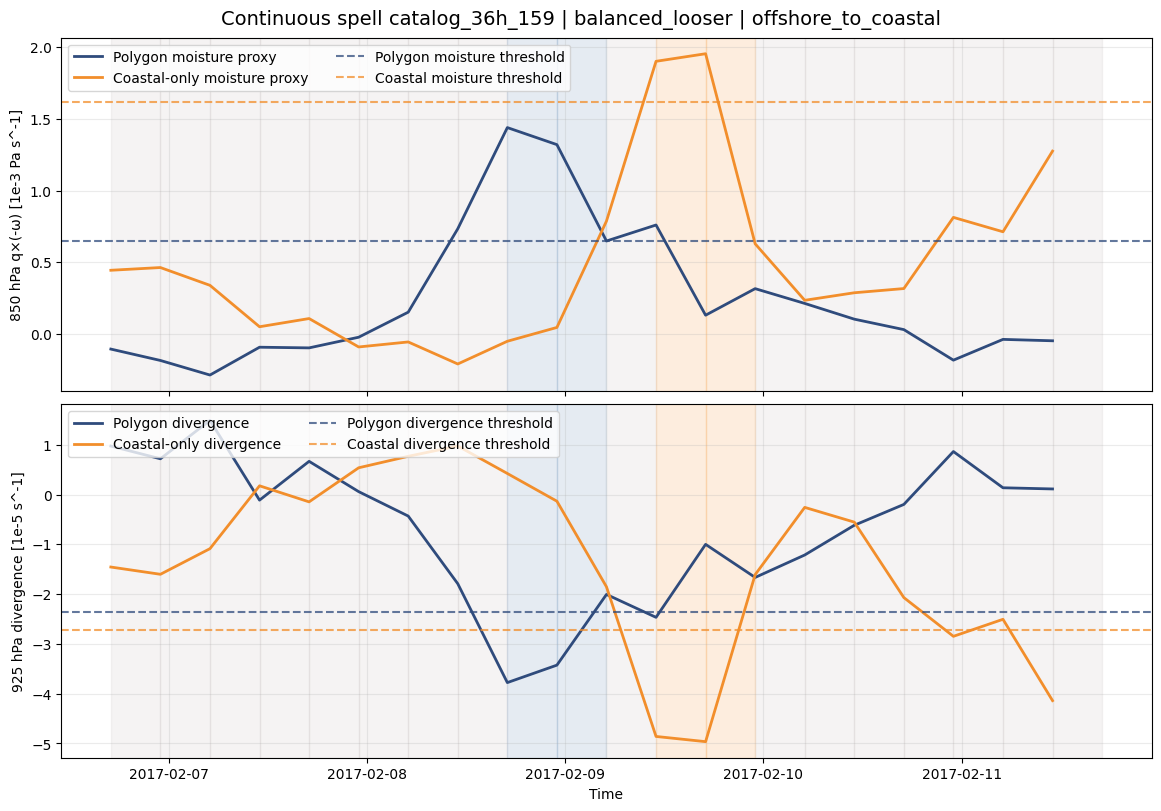

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_continuous_spell_profile_balanced_looser_gap36h_pad48h_fullrun_allprofiles_allspells.png
Selected continuous timing-group summary


,catalog_spell_id,threshold_profile,time_step_hours,continuous_spell_regime_path,continuous_clear_sequence,time_step_count,offshore_support_step_count,coastal_support_step_count,mixed_support_step_count,weak_step_count,...,analysis_start,analysis_end,first_event_peak,last_event_peak,first_event_peak_jst,last_event_peak_jst,spell_duration_hours,analysis_window_hours,max_internal_gap_hours,base_metric_status
158,catalog_36h_159,balanced_looser,6,offshore_to_coastal,offshore_jpcz_core -> coastal_interaction,20,2,2,0,16,...,2017-02-06 17:00:00,2017-02-11 14:00:00,2017-02-09 01:00:00,2017-02-09 01:00:00,2017-02-09 10:00:00,2017-02-09 10:00:00,21.0,117.0,417.0,ok


In [28]:
required_globals = [
    "active_candidate_thresholds_df",
    "continuous_labeled_timeseries_df",
    "continuous_summary_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f"Run the earlier Notebook 25 cells first. Missing globals: {missing_globals}")

plot_summary_df = continuous_summary_df.loc[
    continuous_summary_df["threshold_profile"] == CONTINUOUS_PLOT_PROFILE
].copy()
if plot_summary_df.empty:
    raise RuntimeError(f"No continuous spell summaries were found for CONTINUOUS_PLOT_PROFILE={CONTINUOUS_PLOT_PROFILE!r}.")

if CONTINUOUS_PLOT_SPELL_ID is not None:
    selected_spell_row = plot_summary_df.loc[plot_summary_df["catalog_spell_id"] == CONTINUOUS_PLOT_SPELL_ID]
    if selected_spell_row.empty:
        raise RuntimeError(
            f"CONTINUOUS_PLOT_SPELL_ID={CONTINUOUS_PLOT_SPELL_ID!r} was not found for profile {CONTINUOUS_PLOT_PROFILE!r}."
        )
    selected_spell_row = selected_spell_row.iloc[0]
else:
    preferred_paths = ["offshore_to_coastal", "coastal_to_offshore", "mixed_or_oscillating", "offshore_only", "coastal_only"]
    selected_spell_row = None
    for preferred_path in preferred_paths:
        subset = plot_summary_df.loc[plot_summary_df["continuous_spell_regime_path"] == preferred_path]
        if not subset.empty:
            selected_spell_row = subset.sort_values(
                ["event_count", "analysis_window_hours"],
                ascending=[False, False],
            ).iloc[0]
            break
    if selected_spell_row is None:
        selected_spell_row = plot_summary_df.sort_values(
            ["event_count", "analysis_window_hours"],
            ascending=[False, False],
        ).iloc[0]

selected_spell_id = str(selected_spell_row["catalog_spell_id"])
selected_threshold_row = active_candidate_thresholds_df.loc[
    active_candidate_thresholds_df["threshold_profile"] == CONTINUOUS_PLOT_PROFILE
].iloc[0]
plot_timeseries_df = continuous_labeled_timeseries_df.loc[
    (continuous_labeled_timeseries_df["threshold_profile"] == CONTINUOUS_PLOT_PROFILE)
    & (continuous_labeled_timeseries_df["catalog_spell_id"].astype(str) == selected_spell_id)
].sort_values("time").copy()
if plot_timeseries_df.empty:
    raise RuntimeError(
        f"No continuous labeled time series were found for spell {selected_spell_id!r} under profile {CONTINUOUS_PLOT_PROFILE!r}."
    )

fig, axes = plt.subplots(2, 1, figsize=(11.5, 8.0), sharex=True, constrained_layout=True)
state_color_map = {
    "offshore_jpcz_core": "#4c78a8",
    "coastal_interaction": "#f58518",
    "mixed_transition": "#9c755f",
    "weak_or_unclear": "#bab0ac",
}
for _, row in plot_timeseries_df.iterrows():
    color = state_color_map.get(str(row["continuous_regime_label"]), "#dddddd")
    axes[0].axvspan(row["time"], row["time"] + pd.Timedelta(hours=CONTINUOUS_TIME_STEP_HOURS), color=color, alpha=0.14)
    axes[1].axvspan(row["time"], row["time"] + pd.Timedelta(hours=CONTINUOUS_TIME_STEP_HOURS), color=color, alpha=0.14)

axes[0].plot(plot_timeseries_df["time"], plot_timeseries_df["polygon_qflux_850_mean"], label="Polygon moisture proxy", color="#2f4b7c", linewidth=2.0)
axes[0].plot(plot_timeseries_df["time"], plot_timeseries_df["coastal_qflux_850_mean"], label="Coastal-only moisture proxy", color="#f28e2b", linewidth=2.0)
axes[0].axhline(float(selected_threshold_row["polygon_qflux_min"]), color="#2f4b7c", linestyle="--", alpha=0.75, label="Polygon moisture threshold")
axes[0].axhline(float(selected_threshold_row["coastal_qflux_split"]), color="#f28e2b", linestyle="--", alpha=0.75, label="Coastal moisture threshold")
axes[0].set_ylabel("850 hPa q×(-ω) [1e-3 Pa s^-1]")
axes[0].legend(loc="upper left", ncol=2)
axes[0].grid(alpha=0.25)

axes[1].plot(plot_timeseries_df["time"], plot_timeseries_df["polygon_div_925_mean"], label="Polygon divergence", color="#2f4b7c", linewidth=2.0)
axes[1].plot(plot_timeseries_df["time"], plot_timeseries_df["coastal_div_925_mean"], label="Coastal-only divergence", color="#f28e2b", linewidth=2.0)
axes[1].axhline(float(selected_threshold_row["polygon_div_max"]), color="#2f4b7c", linestyle="--", alpha=0.75, label="Polygon divergence threshold")
axes[1].axhline(float(selected_threshold_row["coastal_div_max"]), color="#f28e2b", linestyle="--", alpha=0.75, label="Coastal divergence threshold")
axes[1].set_ylabel("925 hPa divergence [1e-5 s^-1]")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper left", ncol=2)
axes[1].grid(alpha=0.25)

fig.suptitle(
    f"Continuous spell {selected_spell_id} | {CONTINUOUS_PLOT_PROFILE} | {selected_spell_row['continuous_spell_regime_path']}",
    fontsize=14,
)
fig.savefig(CONTINUOUS_PLOT_PATH, dpi=170, bbox_inches="tight")
plt.show()
maybe_copy_to_drive(CONTINUOUS_PLOT_PATH)

print("Selected continuous timing-group summary")
display(pd.DataFrame([selected_spell_row]))


In [29]:
required_globals = [
    "objective_df",
    "candidate_thresholds_df",
    "active_candidate_thresholds_df",
    "catalog_spell_window_df",
    "spell_runtime_window_df",
    "continuous_base_timeseries_df",
    "continuous_base_spell_summary_df",
    "continuous_profile_summary_df",
    "continuous_examples_df",
    "catalog_spell_events_df",
    "continuous_summary_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f"Run the earlier Notebook 25 cells first. Missing globals: {missing_globals}")

multi_event_group_count = int((catalog_spell_window_df["event_count"] > 1).sum())
single_event_group_count = int((catalog_spell_window_df["event_count"] == 1).sum())
two_event_group_count = int((catalog_spell_window_df["event_count"] == 2).sum())
three_event_group_count = int((catalog_spell_window_df["event_count"] == 3).sum())
other_multi_event_group_count = int((catalog_spell_window_df["event_count"] > 3).sum())

base_ok_count = int((continuous_base_spell_summary_df["base_metric_status"] == "ok").sum())
base_total_count = int(len(continuous_base_spell_summary_df))
base_time_step_count = int(
    pd.to_numeric(continuous_base_spell_summary_df.get("time_step_count", 0), errors="coerce")
    .fillna(0)
    .sum()
)

profile_order = candidate_thresholds_df["threshold_profile"].tolist()
continuous_profile_summary_ordered_df = (
    continuous_profile_summary_df
    .set_index("threshold_profile")
    .reindex(profile_order)
    .reset_index()
)

peak_episode_summary_path = TIMING_EXPORT_DIR / f"objective_regime_episode_summary_gap{CONTINUOUS_SPELL_GAP_HOURS:02d}h.csv"
if not peak_episode_summary_path.exists():
    restore_from_drive_cache(peak_episode_summary_path)

peak_episode_summary_df = pd.DataFrame()
peak_offshore_to_coastal = np.nan
peak_coastal_to_offshore = np.nan
peak_directional_transition_total = np.nan
if peak_episode_summary_path.exists():
    peak_episode_summary_df = pd.read_csv(peak_episode_summary_path)
    if {"objective_episode_regime_path", "n_episodes"}.issubset(peak_episode_summary_df.columns):
        peak_counts = peak_episode_summary_df.set_index("objective_episode_regime_path")["n_episodes"].to_dict()
        peak_offshore_to_coastal = int(peak_counts.get("offshore_to_coastal", 0))
        peak_coastal_to_offshore = int(peak_counts.get("coastal_to_offshore", 0))
        peak_directional_transition_total = int(peak_offshore_to_coastal + peak_coastal_to_offshore)

strongest_profile_row = continuous_profile_summary_ordered_df.sort_values(
    ["directional_transition_spells", "offshore_to_coastal_spells", "coastal_only_spells"],
    ascending=[False, False, False],
).iloc[0]

event_sequence_summary_df = (
    catalog_spell_events_df
    .sort_values(["catalog_spell_id", "event_peak"])
    .groupby("catalog_spell_id", sort=False)
    .agg(
        grouped_event_count=("event_index", "size"),
        event_indices=("event_index", lambda values: ", ".join(str(int(value)) for value in values)),
        event_level_sequence=("objective_regime_label", lambda values: " -> ".join(str(value) for value in values)),
    )
    .reset_index()
)

transition_paths = ["offshore_to_coastal", "coastal_to_offshore", "mixed_or_oscillating"]
transition_timing_group_summary_df = (
    continuous_summary_df
    .loc[continuous_summary_df["continuous_spell_regime_path"].isin(transition_paths)]
    .merge(event_sequence_summary_df, on="catalog_spell_id", how="left")
)
if "event_count" not in transition_timing_group_summary_df.columns and "grouped_event_count" in transition_timing_group_summary_df.columns:
    transition_timing_group_summary_df["event_count"] = transition_timing_group_summary_df["grouped_event_count"]
elif "event_count" in transition_timing_group_summary_df.columns and "grouped_event_count" in transition_timing_group_summary_df.columns:
    transition_timing_group_summary_df["event_count"] = transition_timing_group_summary_df["event_count"].fillna(
        transition_timing_group_summary_df["grouped_event_count"]
    )
transition_timing_group_summary_df = transition_timing_group_summary_df.sort_values(
    ["threshold_profile", "event_count", "catalog_spell_id"], ascending=[True, False, True]
).reset_index(drop=True)

multi_event_transition_timing_group_summary_df = transition_timing_group_summary_df.loc[
    transition_timing_group_summary_df["event_count"] > 1
].reset_index(drop=True)

standout_group_df = event_sequence_summary_df.loc[event_sequence_summary_df["catalog_spell_id"] == "catalog_36h_134"]

print("Notebook 25 summary")
print(f"- Current run tag: {CONTINUOUS_RUN_TAG}")
print(f"- Smoke test mode: {SMOKE_TEST_MODE}")
print()
print("Plain-language timing-group summary")
print(f"- Stage 1 grouped the {len(objective_df)} original catalog events into {len(catalog_spell_window_df)} catalog timing groups.")
print(f"- There are {multi_event_group_count} multi-event catalog timing groups.")
print(f"- The other {len(catalog_spell_window_df)} - {multi_event_group_count} = {single_event_group_count} timing groups are single-event groups.")
print(f"- Out of the {len(objective_df)} original events, {two_event_group_count} timing groups contain 2 events and {three_event_group_count} timing groups contain 3 events.")
if other_multi_event_group_count == 0:
    print("- No timing groups contain more than 3 events, so everything else stayed alone.")
else:
    print(f"- {other_multi_event_group_count} timing groups contain more than 3 events.")
print()
print("What happened in each stage")
print(f"- Stage 1 worked: {len(objective_df)} events became {len(catalog_spell_window_df)} catalog timing groups.")
print(f"- Stage 2 worked: all {base_total_count} timing groups got usable base continuous means.")
print(f"- base_metric_status = ok for {base_ok_count} of {base_total_count} timing groups.")
print(f"- Stage 2 wrote {base_time_step_count} total continuous 6-hour time steps across those timing groups.")
print(f"- Stage 3 worked: all {len(active_candidate_thresholds_df)} candidate threshold profiles were applied through time.")
print("- This produced a real continuous evolution summary rather than relying only on peak-event ordering.")
print()
if pd.notna(peak_directional_transition_total):
    print("Peak-event versus continuous timing-group result")
    print(
        f"- Peak-event method in Notebook 23 gave almost nothing at the same {CONTINUOUS_SPELL_GAP_HOURS} h gap: "
        f"{int(peak_offshore_to_coastal)} offshore_to_coastal and {int(peak_coastal_to_offshore)} coastal_to_offshore episodes "
        f"({int(peak_directional_transition_total)} directional transitions total)."
    )
    print("- The continuous timing-group method recovered many more transitions than the peak-event method.")
    print()

print("Continuous timing-group counts by threshold profile")
for profile_name in profile_order:
    profile_row = continuous_profile_summary_ordered_df.loc[
        continuous_profile_summary_ordered_df["threshold_profile"] == profile_name
    ]
    if profile_row.empty:
        continue
    profile_row = profile_row.iloc[0]
    print(profile_name)
    print(f"- {int(profile_row['offshore_only_spells'])} offshore_only")
    print(f"- {int(profile_row['coastal_only_spells'])} coastal_only")
    print(f"- {int(profile_row['offshore_to_coastal_spells'])} offshore_to_coastal")
    print(f"- {int(profile_row['coastal_to_offshore_spells'])} coastal_to_offshore")
    if int(profile_row.get('mixed_or_oscillating_spells', 0)) > 0:
        print(f"- {int(profile_row['mixed_or_oscillating_spells'])} mixed_or_oscillating")
    print(f"- {int(profile_row['weak_only_spells'])} weak_only")
    print(f"- {int(profile_row['directional_transition_spells'])} directional transitions total")
    print()

print("Main scientific takeaway")
print(
    f"- The strongest transition-producing profile is {strongest_profile_row['threshold_profile']}: "
    f"{int(strongest_profile_row['directional_transition_spells'])} directional transitions total, "
    f"{int(strongest_profile_row['offshore_to_coastal_spells'])} offshore -> coastal, "
    f"and {int(strongest_profile_row['coastal_to_offshore_spells'])} coastal -> offshore."
)
print("- That is much more informative for the evolution question than the old peak-event result.")
print()
transition_group_count_any_profile = int(transition_timing_group_summary_df["catalog_spell_id"].nunique())
multi_event_transition_group_count_any_profile = int(multi_event_transition_timing_group_summary_df["catalog_spell_id"].nunique())
print(
    f"- {transition_group_count_any_profile} catalog timing groups transition under at least one threshold profile, and "
    f"{multi_event_transition_group_count_any_profile} of those are multi-event timing groups."
)
if not standout_group_df.empty:
    standout_row = standout_group_df.iloc[0]
    print(
        f"- A clean grouped transition case is {standout_row['catalog_spell_id']}: event indices "
        f"{standout_row['event_indices']} with event-level sequence {standout_row['event_level_sequence']}."
    )
print()
print("Transition timing-group summary across profiles")
display(
    transition_timing_group_summary_df[[
        "catalog_spell_id",
        "threshold_profile",
        "continuous_spell_regime_path",
        "continuous_clear_sequence",
        "event_count",
        "grouped_event_count",
        "event_indices",
        "event_level_sequence",
        "offshore_to_coastal_lag_hours",
        "coastal_to_offshore_lag_hours",
        "spell_duration_hours",
        "analysis_window_hours",
    ]]
)
if not multi_event_transition_timing_group_summary_df.empty:
    print()
    print("Multi-event transition timing groups")
    display(
        multi_event_transition_timing_group_summary_df[[
            "catalog_spell_id",
            "threshold_profile",
            "continuous_spell_regime_path",
            "continuous_clear_sequence",
            "event_count",
            "grouped_event_count",
            "event_indices",
            "event_level_sequence",
            "offshore_to_coastal_lag_hours",
            "coastal_to_offshore_lag_hours",
            "spell_duration_hours",
            "analysis_window_hours",
        ]]
    )
print()
print("Saved outputs")
print(f"- Candidate threshold finalists: {CONTINUOUS_CANDIDATE_THRESHOLDS_PATH}")
print(f"- Catalog timing-group membership: {CONTINUOUS_SPELL_EVENT_PATH}")
print(f"- Catalog timing-group windows: {CONTINUOUS_SPELL_WINDOW_PATH}")
print(f"- Base continuous timing-group time series: {CONTINUOUS_BASE_TIMESERIES_PATH}")
print(f"- Base timing-group summary: {CONTINUOUS_BASE_SPELL_SUMMARY_PATH}")
print(f"- Labeled continuous timing-group time series: {CONTINUOUS_LABELED_TIMESERIES_PATH}")
print(f"- Continuous timing-group summary: {CONTINUOUS_SUMMARY_PATH}")
print(f"- Continuous profile summary: {CONTINUOUS_PROFILE_SUMMARY_PATH}")
print(f"- Continuous timing-group examples: {CONTINUOUS_EXAMPLES_PATH}")
print(f"- Selected timing-group plot: {CONTINUOUS_PLOT_PATH}")
print()
print("Compact profile summary table")
display(
    continuous_profile_summary_ordered_df[[
        "threshold_profile",
        "spell_count",
        "offshore_only_spells",
        "coastal_only_spells",
        "offshore_to_coastal_spells",
        "coastal_to_offshore_spells",
        "mixed_or_oscillating_spells",
        "weak_only_spells",
        "directional_transition_spells",
        "median_offshore_to_coastal_lag_hours",
        "median_coastal_to_offshore_lag_hours",
    ]]
)




Notebook 25 summary
- Current run tag: fullrun_allprofiles_allspells
- Smoke test mode: False

Plain-language timing-group summary
- Stage 1 grouped the 201 original catalog events into 177 catalog timing groups.
- There are 20 multi-event catalog timing groups.
- The other 177 - 20 = 157 timing groups are single-event groups.
- Out of the 201 original events, 16 timing groups contain 2 events and 4 timing groups contain 3 events.
- No timing groups contain more than 3 events, so everything else stayed alone.

What happened in each stage
- Stage 1 worked: 201 events became 177 catalog timing groups.
- Stage 2 worked: all 177 timing groups got usable base continuous means.
- base_metric_status = ok for 177 of 177 timing groups.
- Stage 2 wrote 3382 total continuous 6-hour time steps across those timing groups.
- Stage 3 worked: all 3 candidate threshold profiles were applied through time.
- This produced a real continuous evolution summary rather than relying only on peak-event ordering

,catalog_spell_id,threshold_profile,continuous_spell_regime_path,continuous_clear_sequence,event_count,grouped_event_count,event_indices,event_level_sequence,offshore_to_coastal_lag_hours,coastal_to_offshore_lag_hours,spell_duration_hours,analysis_window_hours
0,catalog_36h_058,balanced_looser,coastal_to_offshore,coastal_interaction -> offshore_jpcz_core,2,2,"61, 62",weak_or_unclear -> offshore_jpcz_core,NaN,42.0,62.0,158.0
1,catalog_36h_039,balanced_looser,coastal_to_offshore,coastal_interaction -> offshore_jpcz_core,1,1,42,coastal_interaction,NaN,30.0,28.0,124.0
2,catalog_36h_063,balanced_looser,coastal_to_offshore,coastal_interaction -> offshore_jpcz_core,1,1,67,offshore_jpcz_core,NaN,42.0,16.0,112.0
3,catalog_36h_066,balanced_looser,offshore_to_coastal,offshore_jpcz_core -> coastal_interaction,1,1,70,weak_or_unclear,12.0,NaN,5.0,101.0
4,catalog_36h_086,balanced_looser,coastal_to_offshore,coastal_interaction -> offshore_jpcz_core,1,1,95,weak_or_unclear,NaN,18.0,29.0,125.0
5,catalog_36h_159,balanced_looser,offshore_to_coastal,offshore_jpcz_core -> coastal_interaction,1,1,178,offshore_jpcz_core,18.0,NaN,21.0,117.0
6,catalog_36h_058,coastal_permissive,coastal_to_offshore,coastal_interaction -> offshore_jpcz_core,2,2,"61, 62",weak_or_unclear -> offshore_jpcz_core,NaN,42.0,62.0,158.0
7,catalog_36h_004,coastal_permissive,offshore_to_coastal,offshore_jpcz_core -> coastal_interaction,1,1,3,offshore_jpcz_core,12.0,NaN,24.0,120.0
8,catalog_36h_021,coastal_permissive,offshore_to_coastal,offshore_jpcz_core -> coastal_interaction,1,1,22,offshore_jpcz_core,18.0,NaN,17.0,113.0
9,catalog_36h_022,coastal_permissive,coastal_to_offshore,coastal_interaction -> offshore_jpcz_core,1,1,23,weak_or_unclear,NaN,42.0,5.0,101.0



Multi-event transition timing groups


,catalog_spell_id,threshold_profile,continuous_spell_regime_path,continuous_clear_sequence,event_count,grouped_event_count,event_indices,event_level_sequence,offshore_to_coastal_lag_hours,coastal_to_offshore_lag_hours,spell_duration_hours,analysis_window_hours
0,catalog_36h_058,balanced_looser,coastal_to_offshore,coastal_interaction -> offshore_jpcz_core,2,2,"61, 62",weak_or_unclear -> offshore_jpcz_core,NaN,42.0,62.0,158.0
1,catalog_36h_058,coastal_permissive,coastal_to_offshore,coastal_interaction -> offshore_jpcz_core,2,2,"61, 62",weak_or_unclear -> offshore_jpcz_core,NaN,42.0,62.0,158.0



Saved outputs
- Candidate threshold finalists: outputs/verification/objective_regime_timing_and_impact/objective_regime_continuous_candidate_thresholds_gap36h_pad48h_fullrun_allprofiles_allspells.csv
- Catalog timing-group membership: outputs/verification/objective_regime_timing_and_impact/objective_regime_continuous_spell_events_gap36h_pad48h_fullrun_allprofiles_allspells.csv
- Catalog timing-group windows: outputs/verification/objective_regime_timing_and_impact/objective_regime_continuous_spell_windows_gap36h_pad48h_fullrun_allprofiles_allspells.csv
- Base continuous timing-group time series: outputs/verification/objective_regime_timing_and_impact/objective_regime_continuous_base_spell_timeseries_gap36h_pad48h_fullrun_allprofiles_allspells.csv
- Base timing-group summary: outputs/verification/objective_regime_timing_and_impact/objective_regime_continuous_base_spell_summary_gap36h_pad48h_fullrun_allprofiles_allspells.csv
- Labeled continuous timing-group time series: outputs/verifica

,threshold_profile,spell_count,offshore_only_spells,coastal_only_spells,offshore_to_coastal_spells,coastal_to_offshore_spells,mixed_or_oscillating_spells,weak_only_spells,directional_transition_spells,median_offshore_to_coastal_lag_hours,median_coastal_to_offshore_lag_hours
0,strict_baseline,177,37,9,2,2,0,127,4,15.0,30.0
1,balanced_looser,177,58,10,2,4,0,103,6,15.0,36.0
2,coastal_permissive,177,39,32,7,4,1,94,11,12.0,42.0
